<a href="https://colab.research.google.com/github/L-Carlos/aulas-machine-learning/blob/main/ML_aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint: Machine Learning & Analytics - PUC Rio (2026)
---
## Aula 1
### Problemas de Classificação

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dados
from sklearn.datasets import load_wine

# selecao de modelo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# avaliacao de modelo
from sklearn.metrics import accuracy_score

# modelos candidatos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#### Carregando o dataset Wine

In [3]:
wine = load_wine()

wine_dataset = pd.DataFrame(wine.data, columns=wine.feature_names)

wine_dataset["target"] = wine.target

wine_dataset.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### Separar dataset em atributos e classe (alvo)

In [5]:
wine_X = wine_dataset.drop(columns="target")
wine_y = wine_dataset["target"]

#### Separar em bases treino e teste

In [7]:
test_size = 0.2
random_state = 2026

In [9]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_X, wine_y, test_size=test_size, random_state=random_state
    )

In [10]:
particoes = 10
kfold = KFold(n_splits=particoes, shuffle=True, random_state=random_state)

#### Modelagem

In [12]:
np.random.seed(random_state)

models = []
results = []
names = []

models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC()))

for name, model in models:
    cv_result = cross_val_score(model, wine_X_train, wine_y_train, cv=kfold, scoring="accuracy")
    results.append(cv_result)
    names.append(name)
    msg = f"{name}: {cv_result.mean():.2f} ({cv_result.std():.3f})"
    print(msg)

KNN: 0.67 (0.112)
CART: 0.90 (0.085)
NB: 0.97 (0.047)
SVM: 0.68 (0.096)


#### Comparação Gráfica

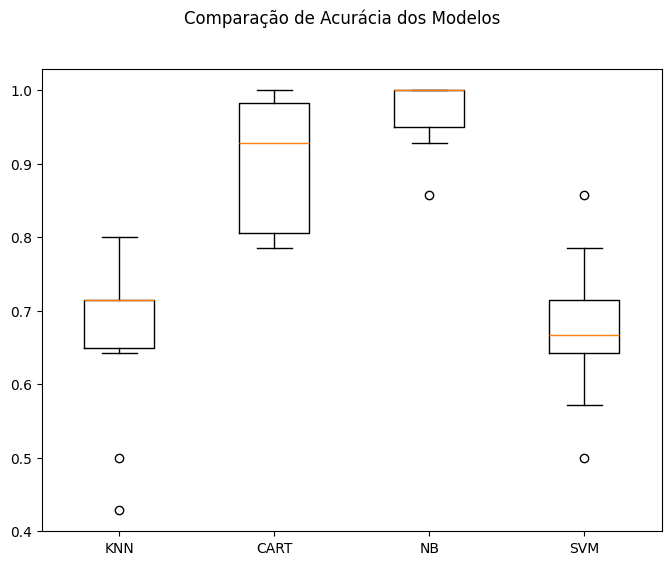

In [16]:
fig = plt.figure(figsize=(8, 6))

fig.suptitle("Comparação de Acurácia dos Modelos")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

In [20]:
model = GaussianNB()
model.fit(wine_X_train, wine_y_train)

predictions = model.predict(wine_X_test)

score = accuracy_score(wine_y_test, predictions)

print(f"Acurácia: {score:.2%}"  )

Acurácia: 100.00%
